### This version of the tool is used to study the lifestyle dataset

The notebook might be a bit messy towards the end, it was mostly used to generate visualizations for the example report.

In [237]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

df

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
1,2,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,True,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
3,4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
4,5,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,True,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,496,38,Rural,Mostly Plant-Based,Often,Walk,Renewable,House,1789,Sometimes,True,4,High,150,2000,Female,Rarely,Recycling,High,4
495,497,25,Urban,Balanced,Sometimes,Public Transit,Non-Renewable,Apartment,987,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,2
496,498,51,Suburban,Mostly Plant-Based,Always,Bike,Mixed,House,1678,Rarely,True,5,High,280,3200,Non-Binary,Sometimes,Recycling,Moderate,5
497,499,32,Rural,Mostly Plant-Based,Rarely,Walk,Mixed,House,1850,Often,False,1,High,397,4076,Female,Rarely,Recycling,Low,5


In [238]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [239]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [240]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [241]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [242]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [243]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0

In [244]:
df['Rating'] = df['Rating'].astype(int)
#df['Rating'] = "Class " + df['Rating'].astype(str)

In [245]:
df.columns

Index(['ParticipantID', 'Age', 'LocalFoodFrequency', 'HomeSize',
       'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness',
       'CommunityInvolvement', 'MonthlyElectricityConsumption',
       'MonthlyWaterConsumption', 'UsingPlasticProducts', 'PhysicalActivities',
       'Rating', 'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'DietType_Balanced', 'DietType_Mostly Animal-Based',
       'TransportationMode_Bike', 'TransportationMode_Car',
       'TransportationMode_Public Transit', 'EnergySource_Mixed',
       'EnergySource_Non-Renewable', 'HomeType_Apartment', 'HomeType_House',
       'Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'DisposalMethods_Combination', 'DisposalMethods_Composting',
       'DisposalMethods_Landfill'],
      dtype='object')

### Highly experimental code, keep the amount of suspected columns to 5 or less (or prepare for a longer processing time)

**This tool combines box plots and scatterplots for detecting overlapping. Pretty neat!**

### It seems this tool is mostly useful with continuous variables. Categoricals get on top of each other, making the scatterlpots for them useless.

## NEW COMPARISON ## - MonthlyElectricityConsumption vs Rating


<Figure size 1000x600 with 0 Axes>

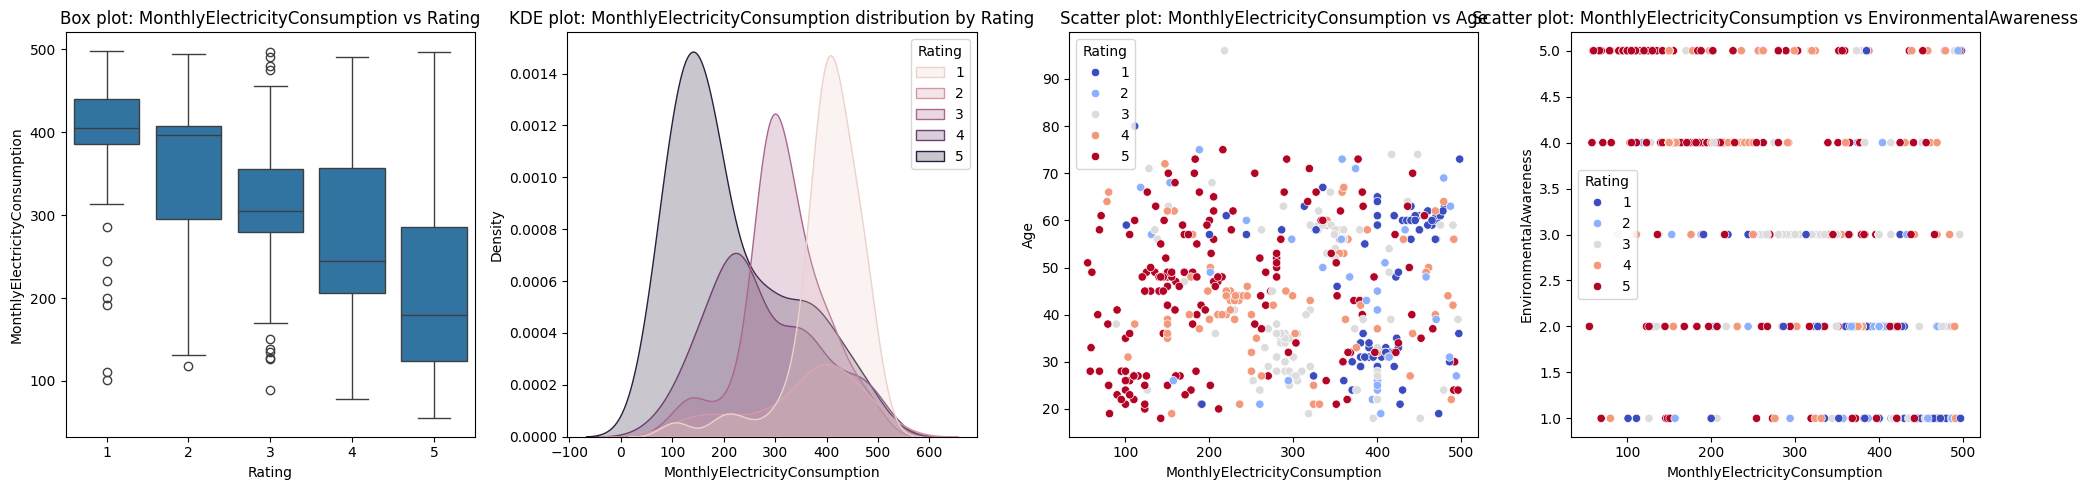

## NEW COMPARISON ## - Age vs Rating


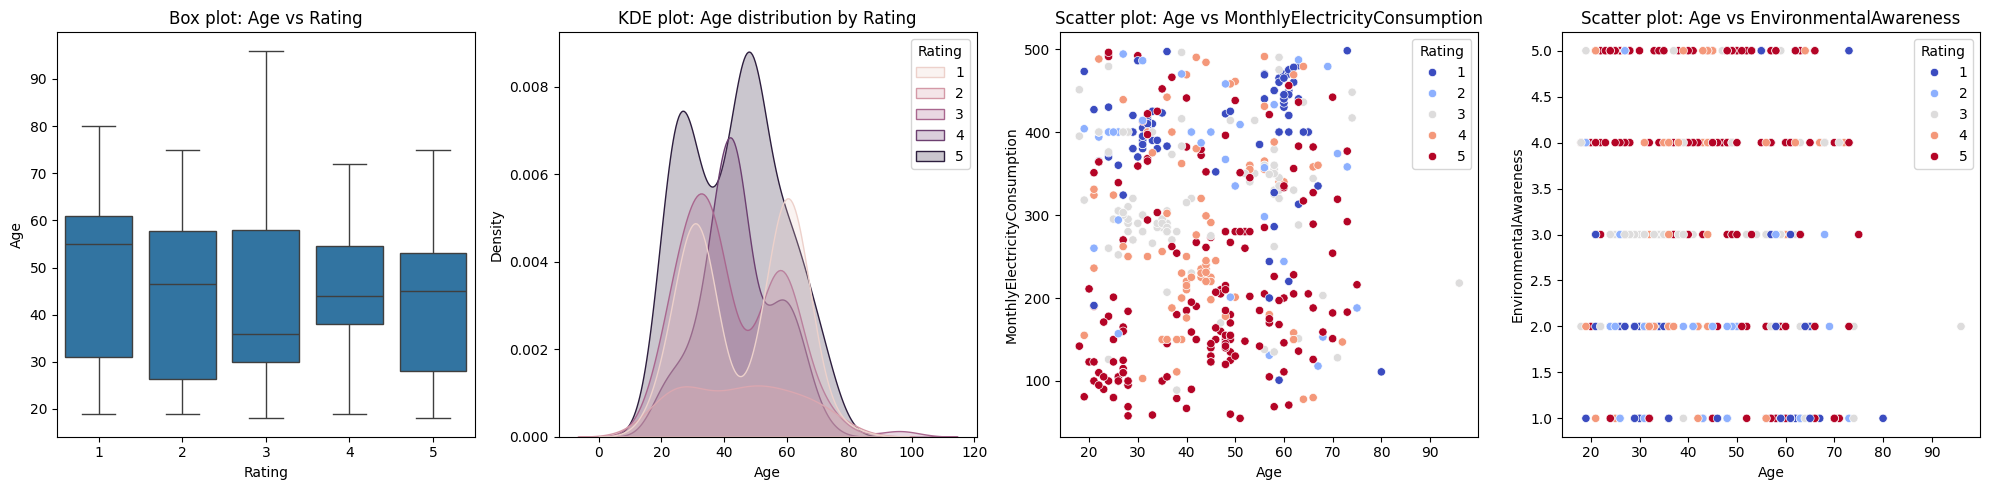

## NEW COMPARISON ## - EnvironmentalAwareness vs Rating


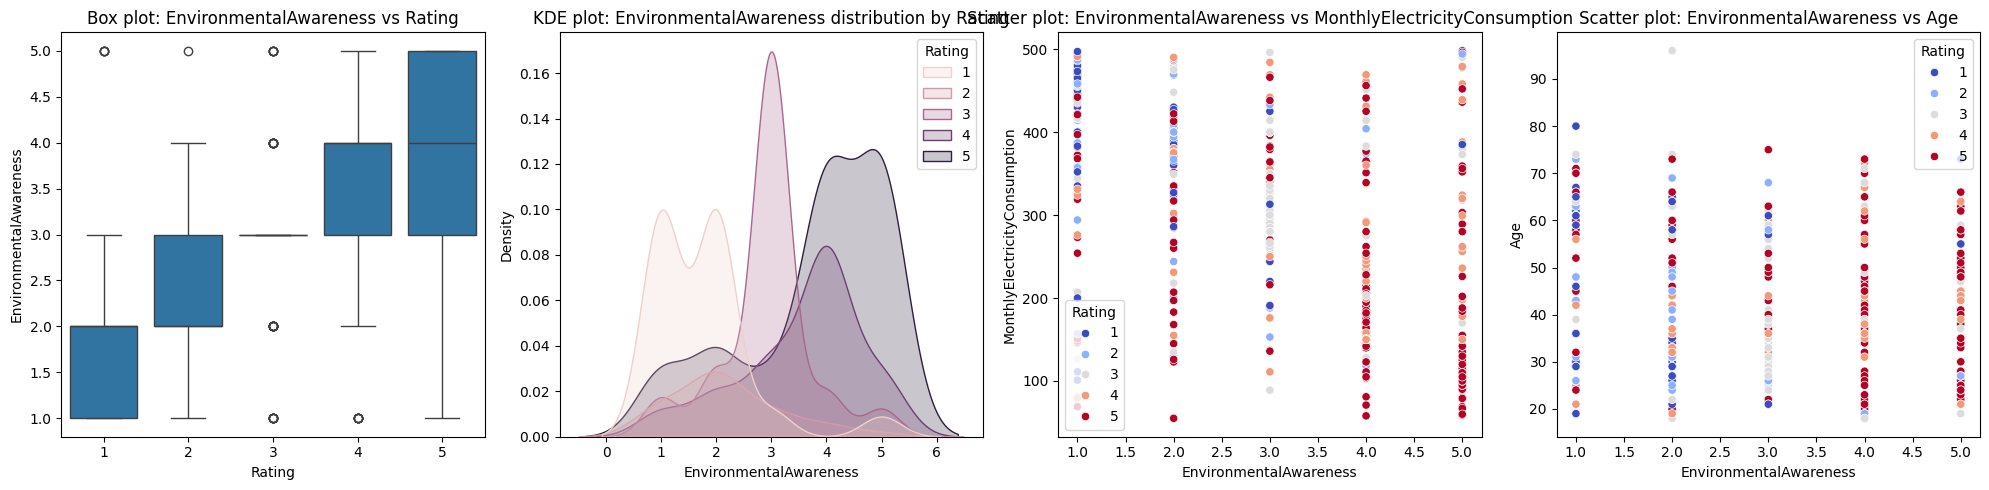

In [257]:
# CODE PARTIALLY GENERATED BY CHATGPT
# modified by instructor to have more features and small finetuning for presentation

# List of suspected columns for overlap
# USE SHAP, LIME, phik-matrix, correlation matrix etc to find columns that seems
# probable for having overlap, noise, redundancy, distribution problems and/or outlier problems
# try to keep the amount of variables to a small number at a time, so you don't slow down the
# process of plot generation below
suspected_columns = ['MonthlyElectricityConsumption', 'Age', 'EnvironmentalAwareness']
target_variable = 'Rating'  # The target variable

# Plot size settings
plt.figure(figsize=(10, 6))

# Iterate through suspected columns to generate box plots and scatter plots in a horizontal layout
for feature in suspected_columns:
    print(f"## NEW COMPARISON ## - {feature} vs {target_variable}")
    num_other_features = len([col for col in suspected_columns if col != feature])
    
    # Create a horizontal grid with 1 row and (1 + num_other_features + 1) columns
    fig, axes = plt.subplots(1, 2 + num_other_features, figsize=(5 * (2 + num_other_features), 5))
    
    # First plot: Box plot for the feature against the target variable
    sns.boxplot(x=target_variable, y=feature, data=df, ax=axes[0])
    axes[0].set_title(f'Box plot: {feature} vs {target_variable}')
    
    # Second plot: KDE plot for the feature, showing distribution by target variable
    sns.kdeplot(x=feature, hue=target_variable, data=df, fill=True, ax=axes[1])
    axes[1].set_title(f'KDE plot: {feature} distribution by {target_variable}')
    
    # Remaining plots: Scatter plots for the feature against every other feature
    for i, other_feature in enumerate([col for col in suspected_columns if col != feature]):
        sns.scatterplot(x=feature, palette="coolwarm", y=other_feature, hue=target_variable, data=df, ax=axes[i + 2])
        axes[i + 2].set_title(f'Scatter plot: {feature} vs {other_feature}')
    
    # Display the entire row of plots
    plt.tight_layout()
    plt.show()

### We will also study Yellowbrick on one of the lectures (since it offers other visualization tools for the same purposes!)

# From this section onward - experimentation with visualizations

Some parts done with ChatGPT + heavy modifications

Let's use seaborn for overlap detection...

<Axes: xlabel='DietType_Mostly Animal-Based', ylabel='EnvironmentalAwareness'>

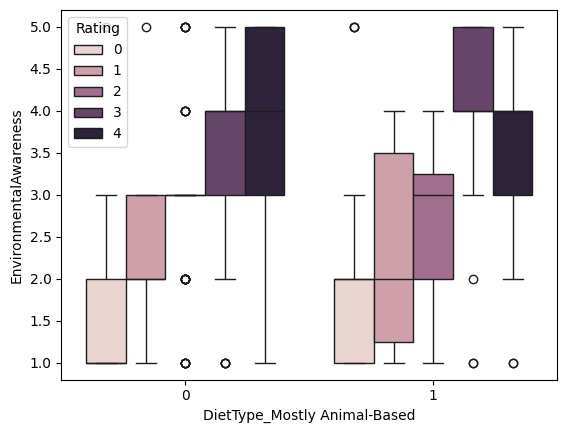

In [247]:
sns.boxplot(x="DietType_Mostly Animal-Based", y="EnvironmentalAwareness", data=df, hue="Rating")

<Axes: xlabel='DietType_Balanced', ylabel='MonthlyElectricityConsumption'>

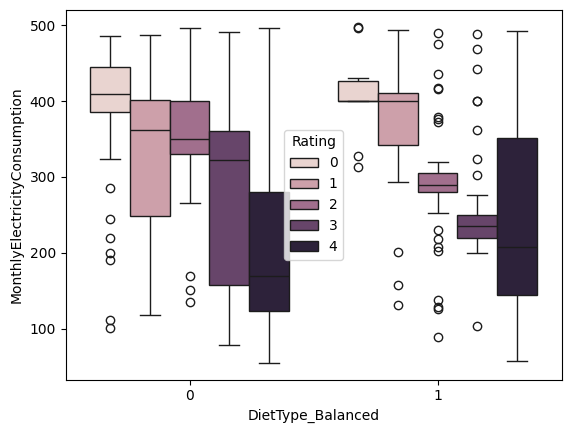

In [248]:
sns.boxplot(x="DietType_Balanced", y="MonthlyElectricityConsumption", data=df, hue="Rating")

In [249]:
# reload the data in original format
df = pd.read_csv("../lifestyle_sustainability_data.csv")


<Axes: xlabel='Rating', ylabel='EnvironmentalAwareness'>

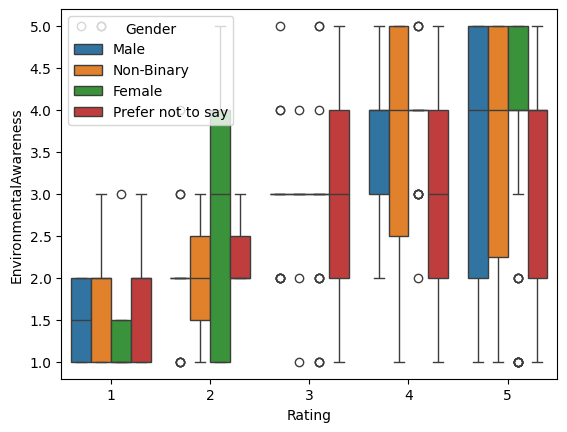

In [250]:
sns.boxplot(x="Rating", y="EnvironmentalAwareness", data=df, hue="Gender")

<Axes: xlabel='Rating', ylabel='EnvironmentalAwareness'>

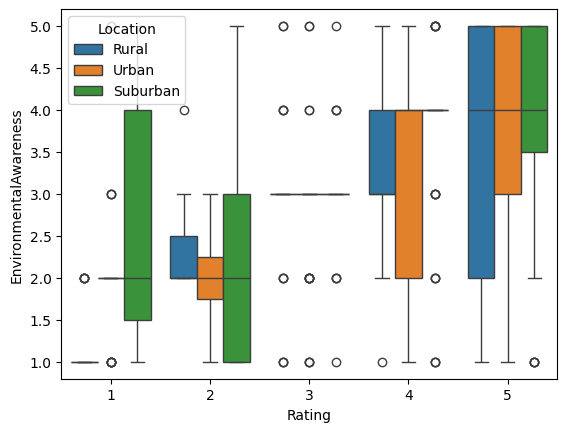

In [251]:
sns.boxplot(x="Rating", y="EnvironmentalAwareness", data=df, hue="Location")


<Axes: xlabel='Rating', ylabel='EnvironmentalAwareness'>

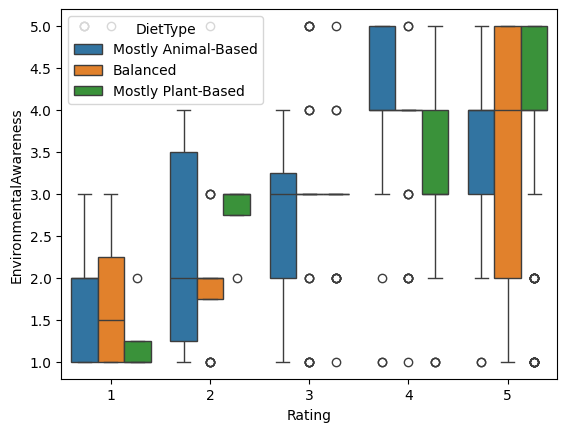

In [252]:
sns.boxplot(x="Rating", y="EnvironmentalAwareness", data=df, hue="DietType")


<Axes: xlabel='Rating', ylabel='MonthlyElectricityConsumption'>

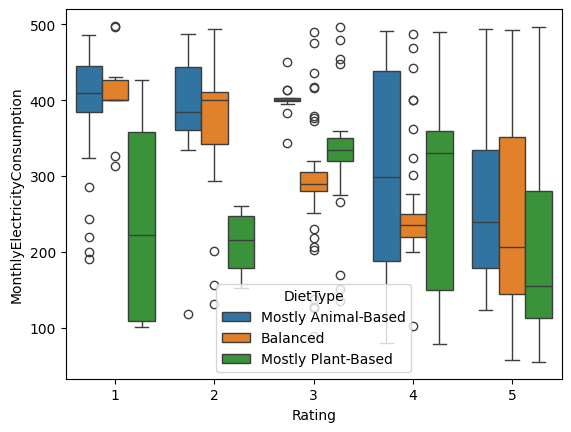

In [253]:
sns.boxplot(x="Rating", y="MonthlyElectricityConsumption", data=df, hue="DietType")

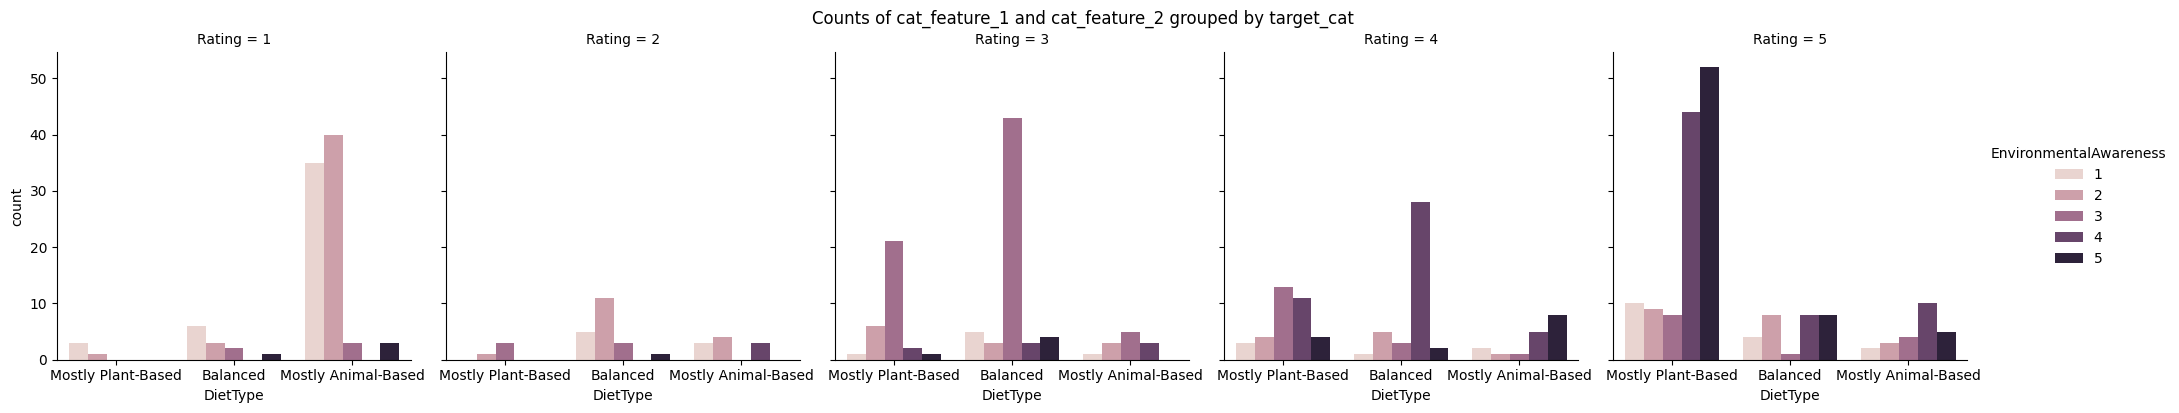

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame columns: 'cat_feature_1', 'cat_feature_2', 'target_cat'

# Count plot, split by target category using 'col' (faceting)
sns.catplot(
    data=df,
    x='DietType',
    hue='EnvironmentalAwareness',
    col='Rating',      # one subplot per target class
    kind='count',
    height=4,
    aspect=1
)

plt.suptitle("Counts of cat_feature_1 and cat_feature_2 grouped by target_cat", y=1.02)
plt.show()


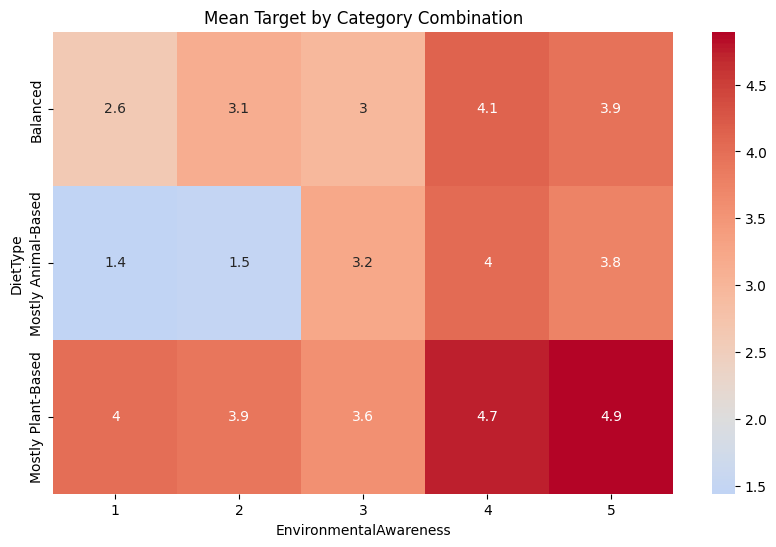

In [255]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# reload the data in original format
df = pd.read_csv("../lifestyle_sustainability_data.csv")


# Example: df has columns 'cat1', 'cat2', 'target'
pivot = df.pivot_table(index='DietType', columns='EnvironmentalAwareness', values='Rating', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='coolwarm', center=2)  # center on mid-point of 0-4
plt.title('Mean Target by Category Combination')
plt.show()


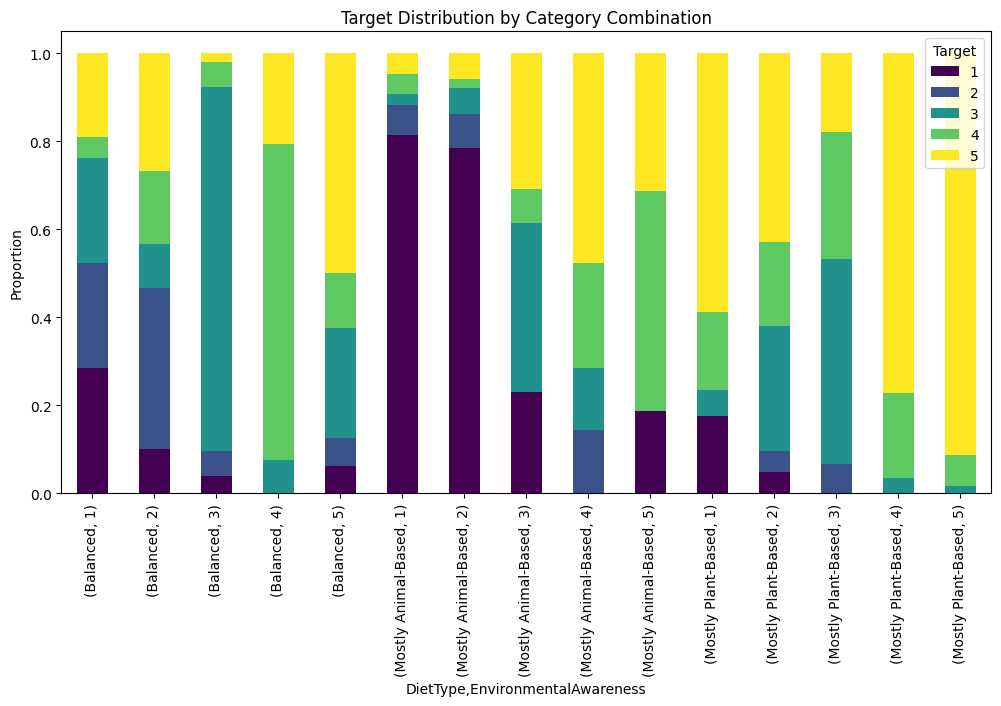

In [256]:
# Optionally group by two categorical variables
group = df.groupby(['DietType', 'EnvironmentalAwareness'])['Rating'].value_counts(normalize=True).unstack().fillna(0)

# Plot
group.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))
plt.ylabel('Proportion')
plt.title('Target Distribution by Category Combination')
plt.legend(title='Target')
plt.show()
